# 5. Example: ETKF Assimilation on progressively more complex cases

Lorenz63, Lorenz96 36 dim, SQGTurb

In this notebook, we'll follow the same steps as in the first example notebook but this time we'll use an Ensemble transform Kalman filter and apply it to increasingly complex test cases. You'll notice that almost all the steps are the same, we just have to tweak how we set up the DACycler. In DABench, all DA Cycler experiments follow the same four A-B-C-D steps:

- A. Generate/load nature run data
- B. Gather observations from nature run
- C. Set up DA Cycler
- D. Run experiment


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import dabench as dab
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
np_rng = np.random.default_rng(seed=50)


# 1. Lorenz63

In [4]:
# A. Create Nature Run
l63 = dab.data.Lorenz63(delta_t=0.01, store_as_jax=True)
nature_run_l63 = l63.generate(n_steps=5000)

In [5]:
# B. Gather observations
# Now we can define the observer:
obs_l63 = dab.observer.Observer(
    nature_run_l63, # Data generator object
    times = nature_run_l63.delta_t*np.arange(0, 5000, 5), # Observation every 5th timestep
    random_location_count = 2, # We'll select 2 elements of the 3 for random sampling
    error_bias = 0.0, # Mean for observation error, Gaussian/Normal distribution
    error_sd = 1.0, # Standard deviation for observation error, Gaussian/Normal distribution
    random_seed=91, # We can specify a random seed. Default is 99
    stationary_observers=True,
    store_as_jax=True
)

# Creating observations using the observer
obs_vec_l63 = obs_l63.observe()

In [6]:
# C. Define forecast model
# We'll use Lorenz 96 as our forecast model for the DA Cycler
# If we gave it the exact same starting conditions as the nature_run, it would
# forecast perfectly. But instead it will be given a statevec with error.
class L63Model(dab.model.Model):                                                                       
    """Defines model wrapper for Lorenz96 to test forecasting."""
    def forecast(self, state_vec, n_steps):
        # IMPORTANT: This method should return the initial state as the 0th step
        new_vec = self.model_obj.generate(x0=state_vec['x'].data, n_steps=n_steps)
        return new_vec.isel(time=-1), new_vec

fc_model_l63 = L63Model(model_obj=l63)

In [7]:
# D. Run DA Cycler
dc = dab.dacycler.ETKF(system_dim=nature_run_l63.system_dim,
                   delta_t=nature_run_l63.delta_t,
                   model_obj=fc_model_l63, # Forecast model we created above
                   ensemble_dim=10 # Ensemble dim for Ensemble Kalman Filter
                  )

In [8]:
nature_run_l63

<xarray.Dataset> Size: 100kB
Dimensions:  (time: 5000, index: 3)
Coordinates:
  * time     (time) float64 40kB 0.0 0.01 0.02 0.03 ... 49.96 49.97 49.98 49.99
  * index    (index) int64 24B 0 1 2
Data variables:
    x        (time, index) float32 60kB ...
Attributes:
    store_as_jax:  True
    system_dim:    3
    delta_t:       0.01

In [9]:
# To generate the ensemble state we'll add random gaussian noise. The ensemble dim will be 10 in this case. 
l63_ensemble_x0 = nature_run_l63.isel(time=0).assign(
    x=(['ensemble','index'],
       nature_run_l63.isel(time=0)['x'].data
       + np_rng.normal(size=(10, 3),scale=3)))


# Run cycler for 3000 timesteps
out_l63 = dc.cycle(
    input_state = l63_ensemble_x0,
    start_time = 0.0,
    obs_vector = obs_vec_l63,
    obs_error_sd = 1.5,
    analysis_window=0.1,
    n_cycles=500,
    return_forecast=True)


In [10]:
out_l63 = out_l63.stack({'time':['cycle','cycle_timestep']}, create_index=False)
out_l63 = out_l63.assign_coords(time=nature_run_l63.time[:out_l63.sizes['time']])

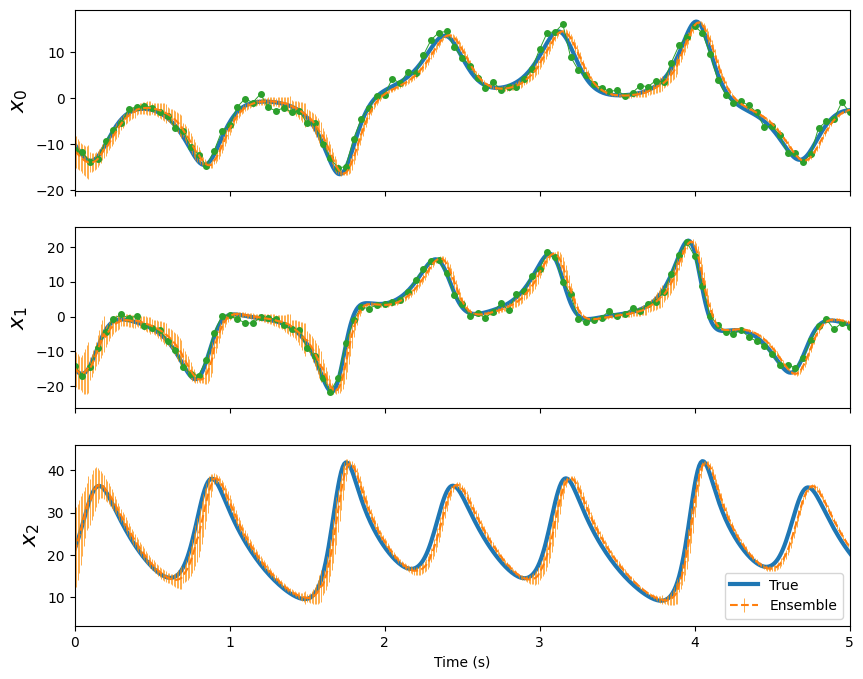

In [11]:
ensemble_range = out_l63['x'].max(dim='ensemble') - out_l63['x'].min(dim='ensemble')
ensemble_mean = out_l63['x'].mean(dim='ensemble')
fig, axes = plt.subplots(3, 1, sharex = True, figsize = (10, 8))
for j, ax in enumerate(axes):
    ax.set_xlim(nature_run_l63['time'].data[0], nature_run_l63['time'].data[500])
    ax.plot(nature_run_l63.time, nature_run_l63['x'].sel(index=j), lw = 3, label = 'True')
    ax.errorbar(ensemble_mean.time, ensemble_mean.sel(index=j),
                yerr=ensemble_range.sel(index=j), linestyle='--', elinewidth=0.5, ecolor='darkorange',
                label='Ensemble')
    if j in obs_vec_l63['system_index']:
        # Since our observations are at different locations at different times,
        # we have to find the appropriate time and location indices that match our observations
        indexing = np.where(j==obs_vec_l63['index'])
        ax.plot(
            obs_vec_l63.time.data, obs_vec_l63['x'].data[:,indexing[0]],
            label='Obs', marker='.', markersize=8, linestyle='-', lw=0.7)
    ax.set_ylabel(r'$x_{:d}$'.format(j), fontsize = 16)
ax.set_xlabel('Time (s)')
ax.legend()
plt.show()

# 2. Lorenz96 - 36dim

We're going to step up in the complexity to a 36-D Lorenz96 model. Does ETKF still do an ok job?

In [12]:
# A. Create Nature Run
l96 = dab.data.Lorenz96(system_dim=36, delta_t=0.01, store_as_jax=True)
nature_run_l96 = l96.generate(n_steps=5000)

In [13]:
# B. Gather observations
# Now we can define the observer:
obs_l96 = dab.observer.Observer(
    nature_run_l96, # Data generator object
    times = nature_run_l96.delta_t*np.arange(0, 5000, 5), # Observation every 5th timestep
    random_location_count = 18, # We'll select 18 elements of the 36 for random sampling
    error_bias = 0.0, # Mean for observation error, Gaussian/Normal distribution
    error_sd = 0.5, # Standard deviation for observation error, Gaussian/Normal distribution
    random_seed=91, # We can specify a random seed. Default is 99
    stationary_observers=True,
    store_as_jax=True
)

# Creating observations using the observer
obs_vec_l96 = obs_l96.observe()

In [14]:
# C. Define forecast model
# We'll use Lorenz 96 as our forecast model for the DA Cycler
# If we gave it the exact same starting conditions as the nature_run, it would
# forecast perfectly. But instead it will be given a statevec with error.
class L96(dab.model.Model):                                                                       
    """Defines model wrapper for Lorenz96 to test forecasting."""
    def forecast(self, state_vec, n_steps):
        # IMPORTANT: This method should return the initial state as the 0th step
        new_vec = self.model_obj.generate(x0=state_vec['x'].data, n_steps=n_steps)
        return new_vec.isel(time=-1), new_vec

fc_model_l96 = L96(model_obj=l96)

In [15]:
# D. Run DA Cycler
dc = dab.dacycler.ETKF(system_dim=nature_run_l96.system_dim,
                   delta_t=nature_run_l96.delta_t,
                   model_obj=fc_model_l96, # Forecast model we created above
                   ensemble_dim=32 # Ensemble dim for Ensemble Kalman Filter
                  )

In [16]:
# To generate the ensemble state we'll add random gaussian noise. The ensemble dim will be 10 in this case. 
l96_ensemble_x0 = nature_run_l96.isel(time=0).assign(
    x=(['ensemble','index'],
       nature_run_l96.isel(time=0)['x'].data
       + np_rng.normal(size=(32, nature_run_l96.system_dim),scale=1.0)))


# Run cycler for 3000 timesteps
out_l96 = dc.cycle(
    input_state = l96_ensemble_x0,
    start_time = 0.0,
    obs_vector = obs_vec_l96,
    obs_error_sd = 0.75,
    analysis_window=0.1,
    n_cycles=500,
    return_forecast=True)


In [17]:
out_l96 = out_l96.stack({'time':['cycle','cycle_timestep']}, create_index=False)
out_l96 = out_l96.assign_coords(time=nature_run_l63.time[:out_l63.sizes['time']])

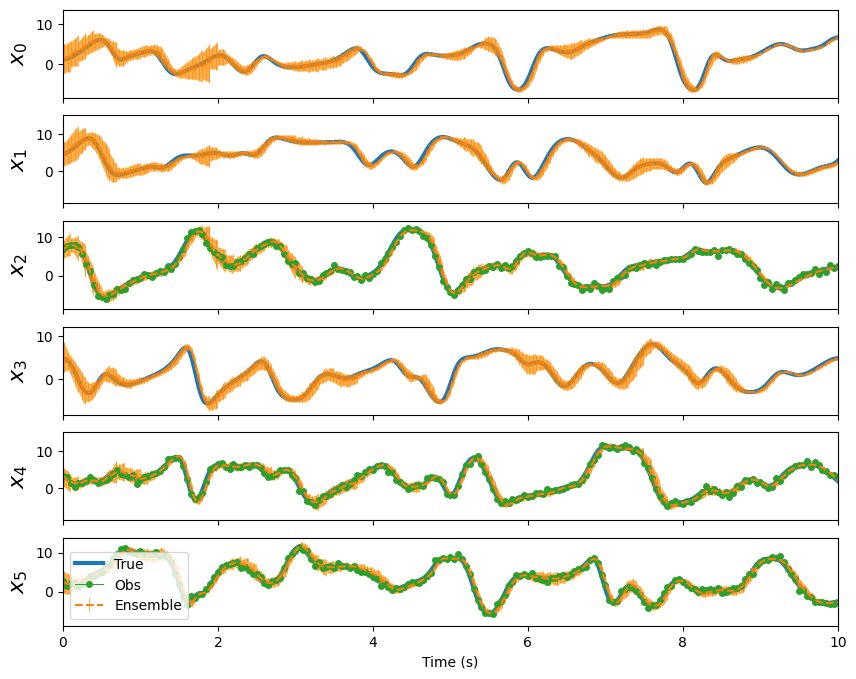

In [18]:
ensemble_range = out_l96['x'].max(dim='ensemble') - out_l96['x'].min(dim='ensemble')
ensemble_mean = out_l96['x'].mean(dim='ensemble')
fig, axes = plt.subplots(6, 1, sharex = True, figsize = (10, 8))
for j, ax in enumerate(axes):
    ax.set_xlim(nature_run_l96['time'].data[0], nature_run_l96['time'].data[1000])
    ax.plot(nature_run_l96.time, nature_run_l96['x'].sel(index=j), lw = 3, label = 'True')
    ax.errorbar(ensemble_mean.time, ensemble_mean.sel(index=j),
                yerr=ensemble_range.sel(index=j), linestyle='--', elinewidth=0.5, ecolor='darkorange',
                label='Ensemble')
    if j in obs_vec_l96['system_index']:
        # Since our observations are at different locations at different times,
        # we have to find the appropriate time and location indices that match our observations
        indexing = np.where(j==obs_vec_l96['index'])
        ax.plot(
            obs_vec_l96.time.data, obs_vec_l96['x'].data[:,indexing[0]],
            label='Obs', marker='.', markersize=8, linestyle='-', lw=0.7)
    ax.set_ylabel(r'$x_{:d}$'.format(j), fontsize = 16)
ax.set_xlabel('Time (s)')
ax.legend()
plt.show()

# 3. SQGTurb

In [19]:
# A. Create Nature Run
sqgturb = dab.data.SQGTurb(store_as_jax=False)
nature_run_sqgturb = sqgturb.generate(n_steps=5000)

In [20]:
# Calculate climatological mean, SD, etc.
clim_std_sqgturb = nature_run_sqgturb['pv'].std(dim='time')

In [21]:
# B. Gather observations
# Now we can define the observer:
obs_sqgturb = dab.observer.Observer(
    nature_run_sqgturb, # Data generator object
    times = nature_run_sqgturb.delta_t*np.arange(0, 1000, 3),
    random_location_count = int(nature_run_sqgturb.system_dim/2),
    error_bias = 0.0, # Mean for observation error, Gaussian/Normal distribution
    error_sd = (clim_std_sqgturb.data*0.1).flatten(), # Standard deviation for observation error, Gaussian/Normal distribution
    random_seed=91, # We can specify a random seed. Default is 99
    stationary_observers=True,
    store_as_jax=False
)

# Creating observations using the observer
obs_vec_sqgturb = obs_sqgturb.observe()

In [22]:
# C. Define forecast model
# If we gave it the exact same starting conditions as the nature_run, it would
# forecast perfectly. But instead it will be given a statevec with error.
class sqgturbModel(dab.model.Model):                                                                       
    """Defines model wrapper for Lorenz96 to test forecasting."""
    def forecast(self, state_vec, n_steps):
        t_final = self.model_obj.delta_t*n_steps
        # IMPORTANT: This method should return the initial state as the 0th step
        new_vec = self.model_obj.generate(x0=self.model_obj.fft2_2dto1d(state_vec['pv'].data),
                                          t_final=t_final)
        return new_vec.isel(time=-1), new_vec

fc_model_sqgturb = sqgturbModel(model_obj=sqgturb)

In [23]:
# D. Run DA Cycler
obs_sqgturb = dab.observer.Observer(
    nature_run_sqgturb, # Data generator object
    times = nature_run_sqgturb.delta_t*np.arange(0, 1000, 3),
    random_location_density = 0.5,
    error_bias = 0.0, # Mean gturb['pv'].isel(time=timestep, level=0))
    error_sd = 300, # Standard deviation for observation error, Gaussian/Normal distribution
    random_seed=91, # We can specify a random seed. Default is 99
    stationary_observers=True,
    store_as_jax=False
)

# Creating observations using the observer
obs_vec_sqgturb = obs_sqgturb.observe()

dc = dab.dacycler.ETKF(system_dim=nature_run_sqgturb.system_dim,
                   delta_t=nature_run_sqgturb.delta_t,
                   model_obj=fc_model_sqgturb, # Forecast model we created above
                   ensemble_dim=64 # Ensemble dim for Ensemble Kalman Filter
                  )

# To generate the ensemble state we'll add random gaussian noise. The ensemble dim will be 10 in this case. 
sqgturb_ensemble_x0 = nature_run_sqgturb.isel(time=0).assign(
    pv=(['ensemble','level','x','y'],
       nature_run_sqgturb.isel(time=0)['pv'].data
       + np_rng.normal(size=(dc.ensemble_dim, 2, 96, 96),scale=clim_std_sqgturb.data*0.25)))


# # Run cycler 
out_sqgturb = dc.cycle(
    input_state = sqgturb_ensemble_x0,
    start_time = 0.0,
    obs_vector = obs_vec_sqgturb,
    obs_error_sd = 400, #clim_std_sqgturb.mean().data*.1,
    analysis_window=nature_run_sqgturb.delta_t*5,
    n_cycles=100,
    return_forecast=True)

2025-06-05 13:46:23.118602: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_scan] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-06-05 13:47:17.343641: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m54.234432148s

********************************
[Compiling module jit_scan] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [24]:
out_sqgturb = out_sqgturb.stack({'time':['cycle','cycle_timestep']}, create_index=False)
out_sqgturb = out_sqgturb.assign_coords(time=nature_run_sqgturb.time[:out_sqgturb.sizes['time']])

In [ ]:
# This is where the actual computation is run, and so it may take quite a while (30+ minutes)
timestep=400
ensemble_range = out_sqgturb['pv'].max(dim='ensemble') - out_sqgturb['pv'].min(dim='ensemble')
ensemble_mean = out_sqgturb['pv'].mean(dim='ensemble')
fig, axs = plt.subplots(3,2, sharex = True, figsize = (5, 8))
axs[0,0].imshow(nature_run_sqgturb['pv'].isel(time=0, level=0))
axs[0,1].imshow(nature_run_sqgturb['pv'].isel(time=timestep, level=0))
axs[1,0].imshow(ensemble_mean['pv'].isel(time=0, level=0))
axs[1,1].imshow(ensemble_mean['pv'].isel(time=timestep, level=0))
axs[2,0].imshow(nature_run_sqgturb['pv'].isel(time=0, level=0) - ensemble_mean['pv'].isel(time=0, level=0),
                cmap='seismic')
axs[2,1].imshow(nature_run_sqgturb['pv'].isel(time=timestep, level=0) - ensemble_mean['pv'].isel(time=timestep, level=0),
                cmap='seismic')

# Set titles
axs[0,0].set_ylabel('Nature Run\ny')
axs[1,0].set_ylabel('Ensemble Mean\ny')
axs[2,0].set_ylabel('Ensemble Mean Error\ny')
for ax in axs.flatten():
    ax.set_xlabel('x')
axs[0,0].set_title('timestep = 0')
axs[0,1].set_title('timestep = {}'.format(timestep))